### [POSET Indicators in Python](https://pub.aimind.so/how-to-create-poset-indicators-in-python-65296c7391f2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('ggplot')

In [2]:
# Loading the wine dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # variety of wine

# Display information for dataframe
display(df.info())

# Sample dataframe records
display(df.sample(10))

# Statistics of dataframe
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

None

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080.0,0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.60,0.77,2.31,600.0,2
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1
16,14.30,1.92,2.72,20.0,120.0,2.80,3.14,0.33,1.97,6.20,1.07,2.65,1280.0,0
119,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.28,0.93,3.05,564.0,1
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
109,11.61,1.35,2.70,20.0,94.0,2.74,2.92,0.29,2.49,2.65,0.96,3.26,680.0,1
141,13.36,2.56,2.35,20.0,89.0,1.40,0.50,0.37,0.64,5.60,0.70,2.47,780.0,2


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [3]:
# Choose a subset of 3 quantitative variables
features = ['alcohol', 'malic_acid', 'color_intensity']
df_subset = df[features].copy()

# Normalization min-max for comparability
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_subset), columns=features)

# Add an ID for reference in the graphs
df_norm['ID'] = df_norm.index

display(df_norm.sample(5))

,alcohol,malic_acid,color_intensity,ID
152,0.547368,0.229249,0.496587,152
145,0.560526,0.559289,0.232082,145
109,0.152632,0.120553,0.116894,109
76,0.526316,0.031621,0.283276,76
114,0.276316,0.128458,0.138225,114


In [4]:
def is_dominant(a, b):
    """Return True if a dominates b."""
    return np.all(a >= b) and np.any(a > b)

# Costruction of the matrice dominance matrix
n = len(df_norm)
D = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(n):
        if i != j:
            if is_dominant(df_norm.loc[i, features].values, df_norm.loc[j, features].values):
                D[i, j] = 1

# Convert into DataFrame for inspection
dominance_df = pd.DataFrame(D, index=df_norm['ID'], columns=df_norm['ID'])
print("Dominance matrix (extract):")
display(dominance_df.iloc[:10, :10])

Dominance matrix (extract):


ID,0,1,2,3,4,5,6,7,8,9
ID,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,1,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0
6,0,1,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0


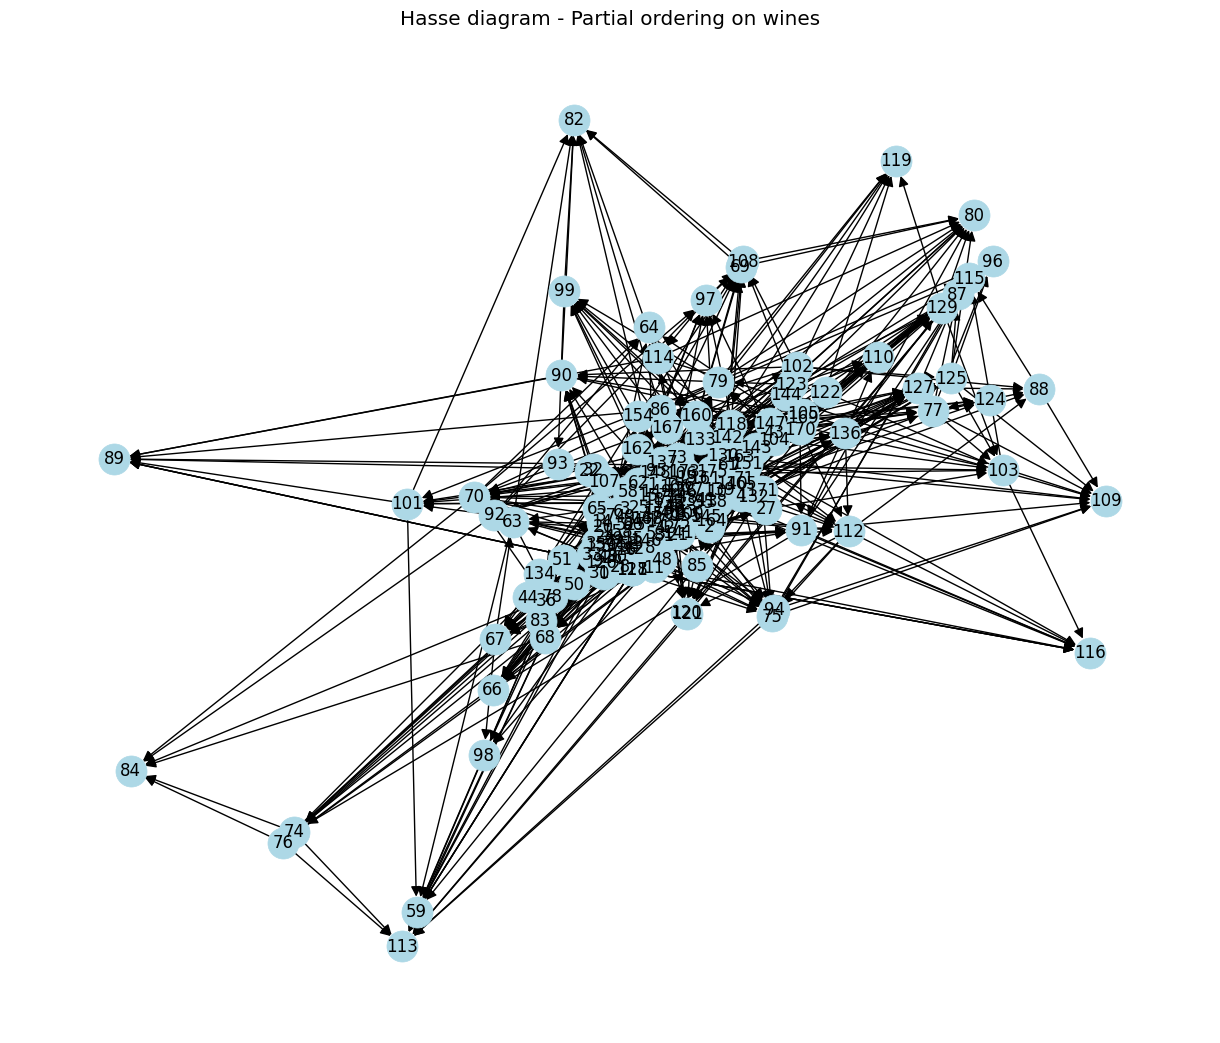

In [5]:
def transitive_reduction(D):
    """Remove the transitive arcs from the dominance matrix."""
    G = nx.DiGraph()
    for i in range(len(D)):
        for j in range(len(D)):
            if D[i, j]:
                G.add_edge(i, j)

    # Transitive reduction
    G_reduced = nx.transitive_reduction(G)
    return G_reduced

# Costruction of graph
G = transitive_reduction(D)

# Visualization
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', arrowsize=15)
plt.title('Hasse diagram - Partial ordering on wines')
plt.show()

In [6]:
incomparable_pairs = []
for i in range(n):
    for j in range(i + 1, n):
        if D[i, j] == 0 and D[j, i] == 0:
            incomparable_pairs.append((i, j))

print(f"Number of incomparable copies: {len(incomparable_pairs)}")
print("Examples of coppie incomparable copies (max 10):")
display(incomparable_pairs[:10])

Number of incomparable copies: 8920
Examples of coppie incomparable copies (max 10):


[(0, 1),
 (0, 2),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 12)]

In [7]:
#  Synthetic index calculation(average of the 3 variables)
df_norm['aggregated_index'] = df_norm[features].mean(axis=1)

# Total ordering
df_ordered = df_norm.sort_values(by='aggregated_index', ascending=False)
print("Top 5 wines according to the aggregated index:")
display(df_ordered[['aggregated_index'] + features].head(5))

Top 5 wines according to the aggregated index:


,aggregated_index,alcohol,malic_acid,color_intensity
173,0.741133,0.705263,0.970356,0.547782
177,0.718530,0.815789,0.664032,0.675768
156,0.689005,0.739474,0.667984,0.659556
158,0.685608,0.871053,0.185771,1.000000
175,0.683390,0.589474,0.699605,0.761092


In [8]:
# Extract the nodi maximal nodes (no successor in the graph)
maximal_nodes = [node for node in G.nodes if G.out_degree(node) == 0]

# Extract the minimal nodes (no predecessor)
minimal_nodes = [node for node in G.nodes if G.in_degree(node) == 0]

print(f"Number of vini maximal wines (not dominated): {len(maximal_nodes)}")
print(f"Number of minimal wines (dominated by all or incomparable): {len(minimal_nodes)}")

Number of vini maximal wines (not dominated): 10
Number of minimal wines (dominated by all or incomparable): 22


In [9]:
# Convert oriented graph to non oriented
G_undirected = G.to_undirected()

# Find the cluster of non comparable nodes (connected components)
components = list(nx.connected_components(G_undirected))

# Filter only the clusters ith at least 3 elements
clusters = [c for c in components if len(c) >= 3]

print(f"Number of clusters of non confrontable wines (≥3 units): {len(clusters)}")
print("Example of clusters (up to 3):")
for c in clusters[:3]:
    print(sorted(c))

Number of clusters of non confrontable wines (≥3 units): 1
Example of clusters (up to 3):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177]


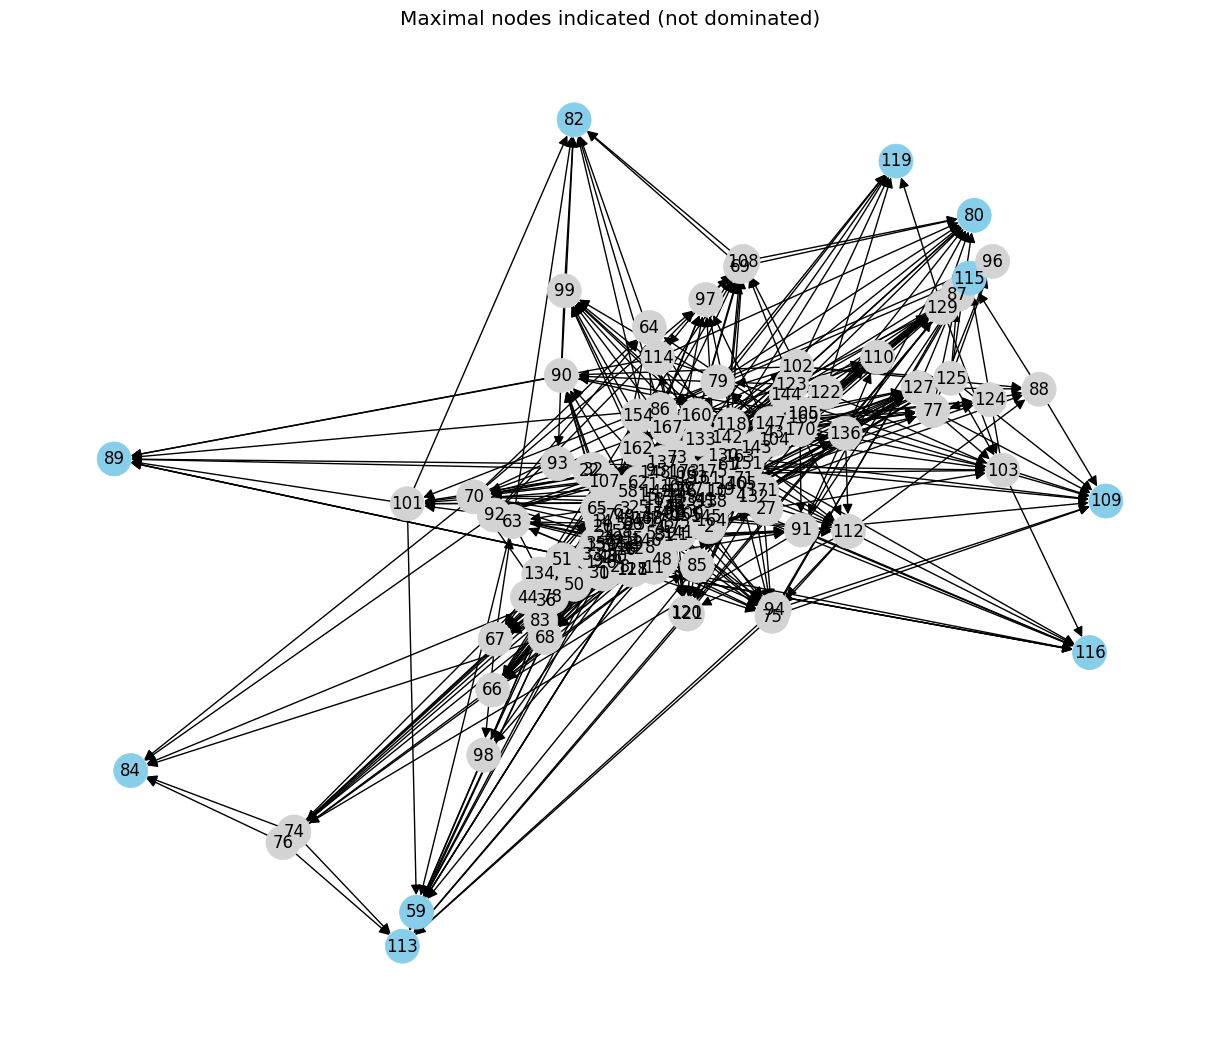

In [10]:
# Color blue for maximal nodes, grey for the others
node_colors = ['skyblue' if node in maximal_nodes else 'lightgrey' for node in G.nodes]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=600, node_color=node_colors, arrowsize=15)
plt.title("Maximal nodes indicated (not dominated)")
plt.show()

In [11]:
# Take 2 node that are incomparable
id1, id2 = incomparable_pairs[0]
print(f"Comparison of wines {id1} and {id2}:")

v1 = df_norm.loc[id1, features]
v2 = df_norm.loc[id2, features]

comparison_df = pd.DataFrame({'wine A': v1, 'wine B': v2})
comparison_df['Dominance'] = ['A > B' if a > b else ('A < B' if a < b else '=') for a, b in zip(v1, v2)]

display(comparison_df)

Comparison of wines 0 and 1:


,wine A,wine B,Dominance
alcohol,0.842105,0.571053,A > B
malic_acid,0.191700,0.205534,A < B
color_intensity,0.372014,0.264505,A > B
